# Investigating Gaussianity of the constructed data terms

In [123]:
import numpy as np
import matplotlib.pyplot as plt

from simulation.radiometer_power import compute_radiometer_power
from gcr.data_and_noise_covariance import construct_data_corrected, quadrature_data_variance_calc_corrected, quadrature_data_variance_calc

Generate 10,000 samples with Gaussian noise in $P_{\rm src}, P_{\rm L}, P_{\rm NS}, T_{\rm }

In [167]:
n_samp = int(1e6)

T_l = 273+20 # K
T_ns = 273+20.5 # K
T_src = 273+15 # K

t_int = 60 # seconds per source
delta_nu = 100e3 # Hz

gain = 10e6

# Gammas
gamma_src = 0.9j
gamma_rec = 0.02+0.01j

gamma_l = 0.01
gamma_ns = 0.01

# Receiver Noise Terms
T_unc = 300
T_0 = 300
T_sin = 20
T_cos = -20

# Temperature Sensor
temp_sens_variance = 0.01**2

p_src = compute_radiometer_power(T_src,T_unc, T_sin, T_cos, T_0,
                                                     gamma_rec, gamma_src, gain, add_noise=False)

p_l = compute_radiometer_power(T_l,T_unc, T_sin, T_cos, T_0,
                                                     gamma_rec, gamma_l, gain, add_noise=False)

p_ns = compute_radiometer_power(T_ns,T_unc, T_sin, T_cos, T_0,
                                                     gamma_rec, gamma_ns, gain, add_noise=False)

d_true = construct_data_corrected(p_src, p_l, p_ns, T_src, T_l, T_ns, gamma_rec, gamma_src, gamma_l, gamma_ns)

In [168]:
p_src_var = (p_src**2) / (delta_nu*t_int)
p_l_var = (p_l**2) / (delta_nu*t_int) 
p_ns_var = (p_ns**2) / (delta_nu*t_int)


p_src_meas = np.abs(np.random.normal(loc=p_src,scale=np.sqrt(p_src_var), size=n_samp))
p_l_meas = np.abs(np.random.normal(loc=p_l,scale=np.sqrt(p_l_var), size=n_samp))
p_ns_meas = np.abs(np.random.normal(loc=p_ns,scale=np.sqrt(p_ns_var), size=n_samp))

T_src_meas = np.abs(np.random.normal(loc=T_src,scale=np.sqrt(temp_sens_variance), size=n_samp))
T_l_meas = np.abs(np.random.normal(loc=T_l,scale=np.sqrt(temp_sens_variance) , size=n_samp))
T_ns_meas = np.abs(np.random.normal(loc=T_ns,scale=np.sqrt(temp_sens_variance), size=n_samp))



# d_meas = noise_wave_gcr.construct_new_data_i(p_src_meas,
#                                               p_l_meas,
#                                               p_ns_meas,
#                                               T_src_meas,
#                                               T_l_meas,
#                                               T_ns_meas,
#                                               gamma_rec,
#                                               gamma_src)
d_meas = construct_data_corrected(p_src=p_src_meas,
                                  p_l=p_l_meas,
                                  p_ns = p_ns_meas,
                                  t_src=T_src_meas,
                                  t_l=T_l_meas,
                                  t_ns=T_ns_meas,
                                  gamma_src=gamma_src,
                                  gamma_l=gamma_l,
                                  gamma_ns=gamma_ns,
                                  gamma_rec=gamma_rec)



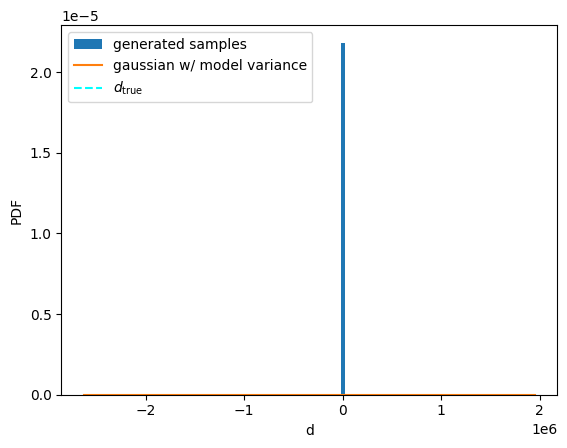

In [169]:
def gaussian(x, mu, sig):
    return (1.0 / (np.sqrt(2.0 * np.pi) * sig) * np.exp(-np.power((x - mu) / sig, 2.0) / 2)
    )



expected_variance = quadrature_data_variance_calc_corrected(p_src=p_src,
                                                            p_l=p_l,
                                                            p_ns=p_ns,
                                                            t_l=T_l,
                                                            t_ns=T_ns,
                                                            gamma_rec=gamma_rec,
                                                            gamma_l=gamma_l,
                                                            gamma_ns=gamma_ns,
                                                            gamma_src=gamma_src,
                                                            t_int_p_src=t_int,
                                                            t_int_p_l=t_int,
                                                            t_int_p_ns=t_int,
                                                            delta_nu=delta_nu,
                                                            temp_sens_variance=temp_sens_variance)

# expected_variance = quadrature_data_variance_calc(p_src=p_src,
#                                                             p_l=p_l,
#                                                             p_ns=p_ns,
#                                                             t_l=T_l,
#                                                             t_ns=T_ns,
#                                                             gamma_rec=gamma_rec,
#                                                             gamma_src=gamma_src,
#                                                             t_int_p_src=t_int,
#                                                             t_int_p_l=t_int,
#                                                             t_int_p_ns=t_int,
#                                                             delta_nu=delta_nu,
#                                                             temp_sens_variance=temp_sens_variance)

x_axis = np.linspace(np.min(d_meas), np.max(d_meas), 100)
y_max = np.max(gaussian(x_axis, d_true, sig=np.sqrt(expected_variance)))

plt.hist(d_meas, 100, density=True, label='generated samples')
plt.plot(x_axis, gaussian(x_axis, d_true, sig=np.sqrt(expected_variance)), label='gaussian w/ model variance')
plt.vlines(x=d_true, ymin=0, ymax=y_max, colors='cyan', linestyles='--', label=r"$d_{\rm true}$")
plt.ylabel('PDF')
plt.xlabel('d')
plt.legend()
plt.show()



In [170]:
print('sample median: ', np.median(d_meas))
print('sample mean: ', np.mean(d_meas))
print('d_true', d_true)

print('Sample Variance', np.var(d_meas))
print('Expected Variance: ',expected_variance)

print(expected_variance / np.var(d_meas))

sample median:  254.87876733049822
sample mean:  251.2811099926601
d_true 256.806456433827
Sample Variance 18832508.076760557
Expected Variance:  141.04198180353998
7.4892829584173524e-06


# Plot limit of the expected and measured variance and offset between the median/mean against true against $T_{\rm ns}-T_{\rm l}$ or $1 / (p_{\rm ns}-p_{\rm l})$

In [128]:
def investigation(iterations_per_sample = 5000,
                  T_l = 293,
                  T_ns_range = np.linspace(293+0.1, 293+200, 1000),
                  T_src = 273+15,
                  T_unc = 300,
                  T_0 = 300,
                  T_sin = 20,
                  T_cos = -20,
                  gamma_src = 0.9j,
                  gamma_l = 0,
                  gamma_ns = 0,
                  gamma_rec = 0.02 + 0.01j):
    t_int = 60 # seconds per source
    delta_nu = 100e3 # Hz

    gain = 10e6
    # Temperature Sensor
    temp_sens_variance = 0.01**2
    T_ns = T_ns_range[0]



    expected_variance_list = []
    sample_median_list = []
    sample_mean_list = []
    sample_variance_list = []
    d_true_list = []
    p_ns_minus_p_l = []


    for T_ns in T_ns_range:
    ##    
        p_src = compute_radiometer_power(T_src,T_unc, T_sin, T_cos, T_0,
                                                            gamma_rec, gamma_src, gain, add_noise=False)

        p_l = compute_radiometer_power(T_l,T_unc, T_sin, T_cos, T_0,
                                                            gamma_rec, gamma_l, gain, add_noise=False)

        p_ns = compute_radiometer_power(T_ns,T_unc, T_sin, T_cos, T_0,
                                                            gamma_rec, gamma_ns, gain, add_noise=False)

        d_true = construct_data_corrected(p_src, p_l, p_ns, T_src, T_l, T_ns, gamma_rec, gamma_src, gamma_l, gamma_ns)

        p_src_var = (p_src**2) / (delta_nu*t_int)
        p_l_var = (p_l**2) / (delta_nu*t_int) 
        p_ns_var = (p_ns**2) / (delta_nu*t_int)


        p_src_meas = np.abs(np.random.normal(loc=p_src,scale=np.sqrt(p_src_var), size=iterations_per_sample))
        p_l_meas = np.abs(np.random.normal(loc=p_l,scale=np.sqrt(p_l_var), size=iterations_per_sample))
        p_ns_meas = np.abs(np.random.normal(loc=p_ns,scale=np.sqrt(p_ns_var), size=iterations_per_sample))

        T_src_meas = np.abs(np.random.normal(loc=T_src,scale=np.sqrt(temp_sens_variance), size=iterations_per_sample))
        T_l_meas = np.abs(np.random.normal(loc=T_l,scale=np.sqrt(temp_sens_variance) , size=iterations_per_sample))
        T_ns_meas = np.abs(np.random.normal(loc=T_ns,scale=np.sqrt(temp_sens_variance), size=iterations_per_sample))

        # d_meas = noise_wave_gcr.construct_new_data_i(p_src_meas,
        #                                               p_l_meas,
        #                                               p_ns_meas,
        #                                               T_src_meas,
        #                                               T_l_meas,
        #                                               T_ns_meas,
        #                                               gamma_rec,
        #                                               gamma_src)
        d_meas = construct_data_corrected(p_src=p_src_meas,
                                        p_l=p_l_meas,
                                        p_ns = p_ns_meas,
                                        t_src=T_src_meas,
                                        t_l=T_l_meas,
                                        t_ns=T_ns_meas,
                                        gamma_src=gamma_src,
                                        gamma_l=gamma_l,
                                        gamma_ns=gamma_ns,
                                        gamma_rec=gamma_rec)
        
        expected_variance = quadrature_data_variance_calc_corrected(p_src=p_src,
                                                                p_l=p_l,
                                                                p_ns=p_ns,
                                                                t_l=T_l,
                                                                t_ns=T_ns,
                                                                gamma_rec=gamma_rec,
                                                                gamma_l=gamma_l,
                                                                gamma_ns=gamma_ns,
                                                                gamma_src=gamma_src,
                                                                t_int_p_src=t_int,
                                                                t_int_p_l=t_int,
                                                                t_int_p_ns=t_int,
                                                                delta_nu=delta_nu,
                                                                temp_sens_variance=temp_sens_variance)
        
        sample_median_list.append(np.median(d_meas))
        sample_mean_list.append(np.mean(d_meas))
        d_true_list.append(d_true)
        
        sample_variance_list.append(np.var(d_meas))
        expected_variance_list.append(expected_variance)
        p_ns_minus_p_l.append(p_ns - p_l)
        pass

    sample_median_list = np.array(sample_median_list)
    sample_mean_list = np.array(sample_mean_list)
    d_true_list = np.array(d_true_list)
    sample_variance_list = np.array(sample_variance_list)
    expected_variance_list = np.array(expected_variance_list)
    p_ns_minus_p_l = np.array(p_ns_minus_p_l)

    return {'sample_mean_list':sample_mean_list,
            'sample_median_list':sample_median_list,
            'd_true_list':d_true_list,
            "sample_variance_list":sample_variance_list,
            "expected_variance_list":expected_variance_list,
            "p_ns_minus_p_l":p_ns_minus_p_l,
            "T_ns_range":T_ns_range,
            "T_l":T_l,
            "T_src":T_src}

    

test_dict = investigation(T_src=1000)


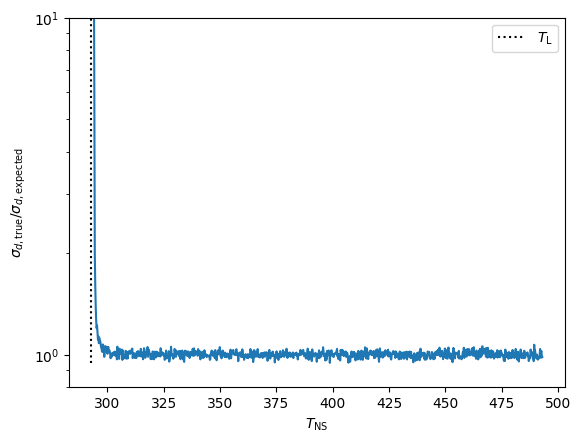

/var/folders/b7/pvn9mnl16d5fxvjs9z9l6p8c0000gp/T/ipykernel_41424/2947556957.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


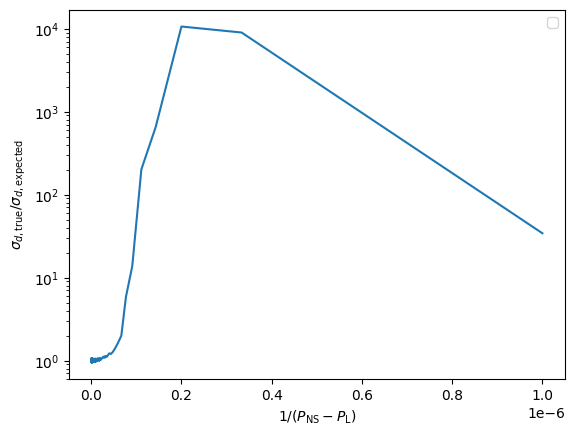

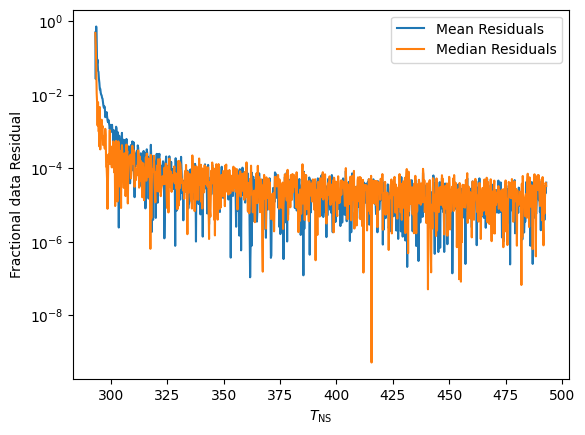

In [129]:


plt.plot(test_dict['T_ns_range'], test_dict['sample_variance_list'] / test_dict['expected_variance_list'])
plt.yscale('log')
plt.ylabel(r'$\sigma_{d, {\rm true}} / \sigma_{d, {\rm expected}}$')
plt.xlabel(r'$T_{\rm NS}$')
plt.ylim(0.8, 10)
plt.vlines(x=test_dict['T_l'], ymin=np.min(test_dict['sample_variance_list'] / test_dict['expected_variance_list']),
           ymax=np.max(test_dict['sample_variance_list'] / test_dict['expected_variance_list']),
           label=r'$T_{\rm L}$', colors='k', linestyles=':')
plt.legend()
plt.show()

plt.plot(1 / test_dict['p_ns_minus_p_l'], test_dict['sample_variance_list'] / test_dict['expected_variance_list'])
plt.yscale('log')
plt.ylabel(r'$\sigma_{d, {\rm true}} / \sigma_{d, {\rm expected}}$')
plt.xlabel(r'$1 / (P_{\rm NS} - P_{\rm L})$')
plt.legend()
plt.show()


plt.plot(test_dict['T_ns_range'],
         np.abs(test_dict['sample_mean_list'] - test_dict['d_true_list']) / test_dict['d_true_list'],
         label='Mean Residuals')
plt.plot(test_dict['T_ns_range'],
         np.abs(test_dict['sample_median_list'] - test_dict['d_true_list']) / test_dict['d_true_list'],
         label='Median Residuals')
plt.ylabel(r'Fractional data Residual')
plt.xlabel(r'$T_{\rm NS}$')
plt.yscale('log')
plt.legend()
plt.show()



In [178]:
def approximate_q_variance(p_src, p_ns, p_l, t_int_eq, delta_nu):
    phi_src, phi_ns, phi_l = 1/3, 1/3, 1/3
    q = (p_src - p_l) / (p_ns - p_l)

    q_var = np.power(q,2) * (
        (np.power(p_src, 2) / (phi_src*np.power(p_src-p_l, 2)) ) + \
        (np.power(p_ns, 2) / (phi_ns * np.power(p_ns-p_l, 2)) ) + \
        ((np.power(p_l, 2)*np.power(p_src - p_ns, 2)) / (phi_l * (np.power(p_ns-p_l, 2)*np.power(p_src - p_l, 2))) )
    ) / (delta_nu * t_int_eq)

    return q_var


def q_test(p_ns_multiplier_range = np.linspace(1.001, 1.2, 500),
           p_src_multiplier_range = np.linspace(0.1, 2, 500),
           t_int_eq = 60,
           delta_nu = 300e3,
           iterations_per_sample = 1000):
    p_l = 10

    p_ns_values = p_l * p_ns_multiplier_range
    p_src_values = p_l * p_src_multiplier_range

    p_l_var = np.power(p_l, 2) / ((t_int_eq / 3) * delta_nu)

    p_ns_var = np.power(p_ns_values, 2) / ((t_int_eq / 3) * delta_nu)
    p_src_var = np.power(p_src_values, 2) / ((t_int_eq / 3) * delta_nu)
    
    p_ns_p_ns, p_src_p_src = np.meshgrid(p_ns_values, p_src_values)

    q_true = (p_src_p_src - p_l) / (p_ns_p_ns - p_l)

    expected_variance = approximate_q_variance(p_src_p_src,
                                               p_ns_p_ns,
                                               p_l,
                                               t_int_eq,
                                               delta_nu)

    q_mean = []
    q_median = []
    q_sample_variance = []

    for p_ns, p_src in zip(p_ns_p_ns.flatten(), p_src_p_src.flatten()):
        p_ns_var = np.power(p_ns, 2) / ((t_int_eq / 3) * delta_nu)
        p_src_var = np.power(p_src, 2) / ((t_int_eq / 3) * delta_nu)

        p_src_meas = np.abs(np.random.normal(loc=p_src,scale=np.sqrt(p_src_var), size=iterations_per_sample))
        p_l_meas = np.abs(np.random.normal(loc=p_l,scale=np.sqrt(p_l_var), size=iterations_per_sample))
        p_ns_meas = np.abs(np.random.normal(loc=p_ns,scale=np.sqrt(p_ns_var), size=iterations_per_sample))

        q_meas = (p_src_meas - p_l_meas) / (p_ns_meas - p_l_meas)
        q_meas_var = np.var(q_meas)
        q_mean.append(q_meas.mean())
        q_median.append(np.median(q_meas))
        q_sample_variance.append(q_meas_var)
    q_mean = np.array(q_mean)
    q_median = np.array(q_median)
    q_sample_variance = np.array(q_sample_variance)

    q_mean = np.reshape(q_mean, shape=expected_variance.shape)
    q_median = np.reshape(q_median, shape=expected_variance.shape)
    q_sample_variance = np.reshape(q_sample_variance, shape=expected_variance.shape)

    return {"p_ns_multiplier_range":p_ns_multiplier_range,
            "p_src_multiplier_range":p_src_multiplier_range,
            "q_true":q_true,
            "q_mean":q_mean,
            "q_median":q_median,
            "q_sample_variance":q_sample_variance,
            "expected_variance":expected_variance}



results_dict = q_test(t_int_eq=0.15,
                      iterations_per_sample=1000,
                      p_ns_multiplier_range=np.geomspace(1+1e-7,
                                                         1.5,
                                                         500))


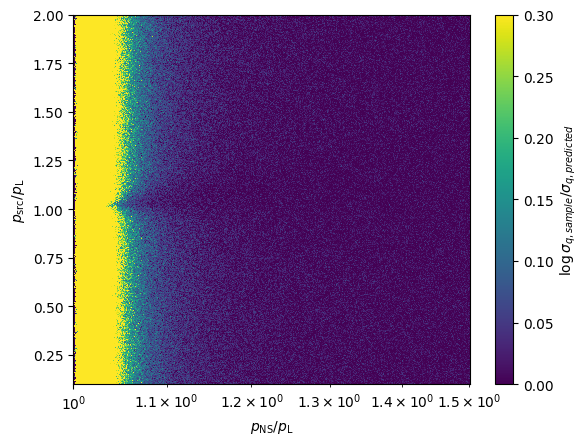

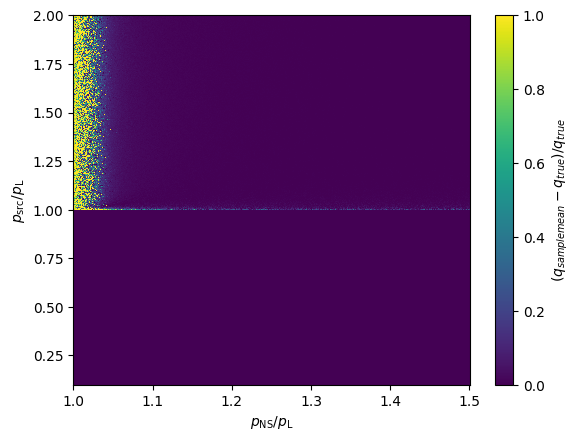

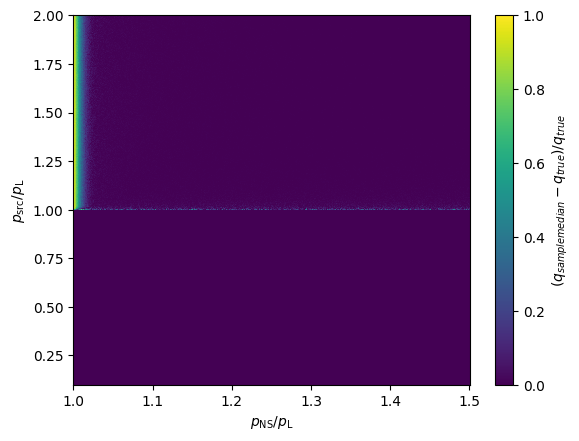

In [179]:

plt.pcolormesh(results_dict["p_ns_multiplier_range"],
               results_dict["p_src_multiplier_range"],
               np.log10(results_dict['q_sample_variance'] / results_dict["expected_variance"]),
               vmin=0, vmax=0.3)
plt.colorbar(label=r'$\log \sigma_{q, sample} / \sigma_{q, predicted}$')
plt.xlabel(r'$p_{\rm NS} / p_{\rm L}$')
plt.xscale('log')
plt.ylabel(r'$p_{\rm src} / p_{\rm L}$')
plt.show()


plt.pcolormesh(results_dict["p_ns_multiplier_range"],
               results_dict["p_src_multiplier_range"],
               np.abs(results_dict['q_mean'] - results_dict["q_true"]) / results_dict['q_true'],
               vmin=0., vmax=1.)
plt.colorbar(label=r'$(q_{sample mean} - q_{true}) / q_{true}$')
plt.xlabel(r'$p_{\rm NS} / p_{\rm L}$')
plt.ylabel(r'$p_{\rm src} / p_{\rm L}$')
plt.show()

plt.pcolormesh(results_dict["p_ns_multiplier_range"],
               results_dict["p_src_multiplier_range"],
               np.abs(results_dict['q_median'] - results_dict["q_true"]) / results_dict['q_true'],
               vmin=0., vmax=1.)
plt.colorbar(label=r'$(q_{sample median} - q_{true}) / q_{true}$')
plt.xlabel(r'$p_{\rm NS} / p_{\rm L}$')
plt.ylabel(r'$p_{\rm src} / p_{\rm L}$')
plt.show()